# Análise exploratória da inflação (IPCA, IPCA-15, IGP-M)

O notebook lê `inflation_monthly` no snapshot `data/gas_flare.sqlite`. O recorte usa a âncora do PPI (`MIN(ppi_daily.report_date)`).

| series | metric | SGS | Conteúdo |
|--------|--------|-----|----------|
| `ipca` | `mom_pct` | 433 | Variação mensal do IPCA (IBGE). CPI oficial. Sai cerca do dia 12 do mês seguinte. |
| `ipca15` | `mom_pct` | 7478 | Variação mensal do IPCA-15 (IBGE). Janela de coleta deslocada. Sai cerca do dia 25 do mês de referência. |
| `igpm` | `mom_pct` | 189 | Variação mensal do IGP-M (FGV, via BCB). Sai no fim do mês. |
| `ipca` | `yoy_pct` | 13522 | IPCA acumulado em 12 meses. **Não** é IPCA-15. |

O IPCA-15 é série mensal. Junto com o IPCA, há duas leituras de inflação ao consumidor por mês. `cpi_latest_mom` usa o IPCA quando o mês existe; senão usa o IPCA-15.

Início nativo neste snapshot: **2022-01**.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8')

cwd = Path.cwd().resolve()
if (cwd / 'src').is_dir() and (cwd / 'data').is_dir():
    project_root = cwd
elif (cwd.parent / 'src').is_dir() and (cwd.parent / 'data').is_dir():
    project_root = cwd.parent
else:
    raise FileNotFoundError(
        'Could not locate proj_IV root (expected src/ and data/). '
        'Open notebooks from proj_IV/ or proj_IV/notebooks/.'
    )

sys.path.insert(0, str(project_root / 'src'))

from db_access import read_engine, resolve_database_url, table_exists

ENGINE = read_engine(project_root)
DATABASE_URL = resolve_database_url(project_root)
DATABASE_URL


'sqlite:////mnt/opencode/proj_IV/data/gas_flare.sqlite'

In [2]:
TABLE = 'inflation_monthly'

def read_table(engine, sql):
    try:
        return pd.read_sql_query(sql, engine)
    except Exception as exc:
        print(f'Skipping query ({exc})')
        return pd.DataFrame()

if not table_exists(ENGINE, TABLE):
    print(f'Missing table: {TABLE} in data/gas_flare.sqlite')
    inf = pd.DataFrame()
else:
    inf = read_table(
        ENGINE,
        'SELECT series, metric, series_name, month, value, unit, source, source_series '
        'FROM inflation_monthly ORDER BY month, series, metric',
    )

ppi_anchor = pd.to_datetime(
    pd.read_sql_query('SELECT MIN(report_date) AS d FROM ppi_daily', ENGINE).iloc[0, 0]
)
print(f'PPI anchor: {ppi_anchor.date()}')

if inf.empty:
    print('inflation_monthly is empty.')
    wide = pd.DataFrame()
else:
    inf['month'] = pd.to_datetime(inf['month'], errors='coerce')
    inf['value'] = pd.to_numeric(inf['value'], errors='coerce')
    inf = inf[inf['month'] >= ppi_anchor].copy()
    inf['col'] = inf['series'].astype(str).str.lower() + '_' + inf['metric'].astype(str).str.lower()
    wide = inf.pivot_table(index='month', columns='col', values='value', aggfunc='last').sort_index()
    if 'ipca_mom_pct' in wide.columns or 'ipca15_mom_pct' in wide.columns:
        ipca = wide['ipca_mom_pct'] if 'ipca_mom_pct' in wide.columns else pd.Series(index=wide.index, dtype=float)
        ipca15 = wide['ipca15_mom_pct'] if 'ipca15_mom_pct' in wide.columns else pd.Series(index=wide.index, dtype=float)
        wide['cpi_latest_mom'] = ipca.combine_first(ipca15)
    print(f'Rows: {len(inf):,}  |  months: {wide.shape[0]}  |  columns: {list(wide.columns)}')
    print(f"Month range: {wide.index.min().date()} to {wide.index.max().date()}")

inf.head()


PPI anchor: 2022-01-05
Rows: 216  |  months: 54  |  columns: ['igpm_mom_pct', 'ipca15_mom_pct', 'ipca_mom_pct', 'ipca_yoy_pct', 'cpi_latest_mom']
Month range: 2022-02-01 to 2026-07-01


,series,metric,series_name,month,value,unit,source,source_series,col
4,igpm,mom_pct,IGP-M monthly variation,2022-02-01,1.83,percent,bcb_sgs,189,igpm_mom_pct
5,ipca,mom_pct,IPCA monthly variation,2022-02-01,1.01,percent,bcb_sgs,433,ipca_mom_pct
6,ipca,yoy_pct,IPCA 12-month accumulated variation,2022-02-01,10.54,percent,bcb_sgs,13522,ipca_yoy_pct
7,ipca15,mom_pct,IPCA-15 monthly variation,2022-02-01,0.99,percent,bcb_sgs,7478,ipca15_mom_pct
8,igpm,mom_pct,IGP-M monthly variation,2022-03-01,1.74,percent,bcb_sgs,189,igpm_mom_pct


In [3]:
if wide.empty:
    print('No inflation series to summarise.')
else:
    latest_rows = []
    for col in wide.columns:
        s = wide[col].dropna()
        if s.empty:
            continue
        latest_rows.append({
            'column': col,
            'n': int(s.shape[0]),
            'first': s.index.min().date(),
            'last': s.index.max().date(),
            'last_value': round(float(s.iloc[-1]), 4),
            'nulls_on_index': int(wide[col].isna().sum()),
        })
    display(pd.DataFrame(latest_rows))
    display(wide.tail(8).round(4))


,column,n,first,last,last_value,nulls_on_index
0,igpm_mom_pct,54,2022-02-01,2026-07-01,-1.16,0
1,ipca15_mom_pct,54,2022-02-01,2026-07-01,0.06,0
2,ipca_mom_pct,54,2022-02-01,2026-07-01,0.07,0
3,ipca_yoy_pct,54,2022-02-01,2026-07-01,4.44,0
4,cpi_latest_mom,54,2022-02-01,2026-07-01,0.07,0


col,igpm_mom_pct,ipca15_mom_pct,ipca_mom_pct,ipca_yoy_pct,cpi_latest_mom
month,,,,,
2025-12-01,-0.01,0.25,0.33,4.26,0.33
2026-01-01,0.41,0.20,0.33,4.44,0.33
2026-02-01,-0.73,0.84,0.70,3.81,0.70
2026-03-01,0.52,0.44,0.88,4.14,0.88
2026-04-01,2.73,0.89,0.67,4.39,0.67
2026-05-01,0.84,0.62,0.58,4.72,0.58
2026-06-01,-0.50,0.41,0.16,4.64,0.16
2026-07-01,-1.16,0.06,0.07,4.44,0.07


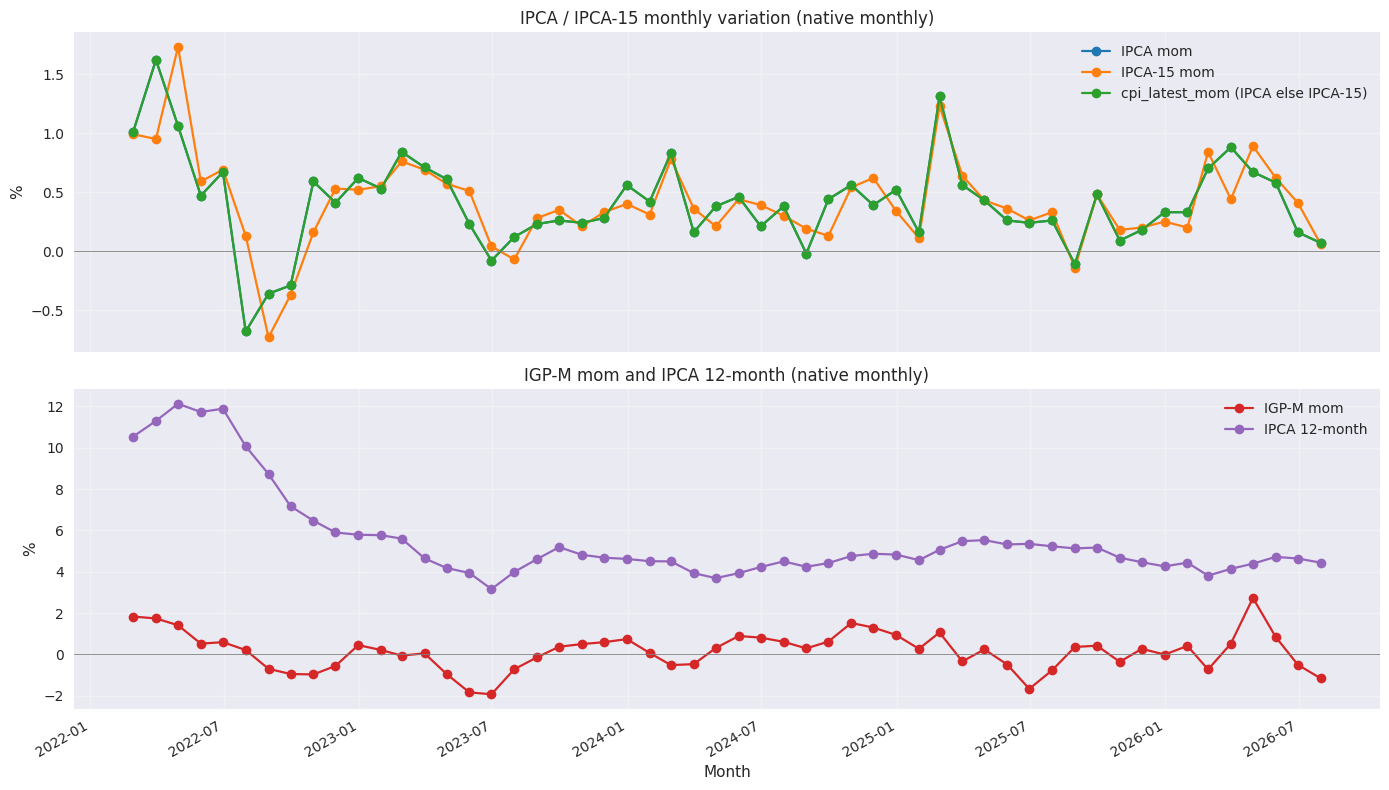

In [4]:
if wide.empty:
    print('No inflation series to plot.')
else:
    month_end = wide.index + pd.offsets.MonthEnd(0)
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax = axes[0]
    for col, label, color in [
        ('ipca_mom_pct', 'IPCA mom', '#1f77b4'),
        ('ipca15_mom_pct', 'IPCA-15 mom', '#ff7f0e'),
        ('cpi_latest_mom', 'cpi_latest_mom (IPCA else IPCA-15)', '#2ca02c'),
    ]:
        if col in wide.columns:
            ax.plot(month_end, wide[col], marker='o', linewidth=1.6, color=color, label=label)
    ax.axhline(0, color='grey', linewidth=0.6)
    ax.set_ylabel('%')
    ax.set_title('IPCA / IPCA-15 monthly variation (native monthly)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1]
    if 'igpm_mom_pct' in wide.columns:
        ax.plot(month_end, wide['igpm_mom_pct'], marker='o', linewidth=1.6, color='#d62728', label='IGP-M mom')
    if 'ipca_yoy_pct' in wide.columns:
        ax.plot(month_end, wide['ipca_yoy_pct'], marker='o', linewidth=1.6, color='#9467bd', label='IPCA 12-month')
    ax.axhline(0, color='grey', linewidth=0.6)
    ax.set_ylabel('%')
    ax.set_xlabel('Month')
    ax.set_title('IGP-M mom and IPCA 12-month (native monthly)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()


In [5]:
if wide.empty:
    print('No inflation series to describe.')
else:
    display(wide.describe().T.round(4))
    if {'ipca_mom_pct', 'ipca15_mom_pct'}.issubset(wide.columns):
        overlap = wide[['ipca_mom_pct', 'ipca15_mom_pct']].dropna()
        print(f'IPCA vs IPCA-15 overlapping months: {len(overlap)}')
        if len(overlap) > 2:
            print('corr(IPCA mom, IPCA-15 mom) =', round(overlap['ipca_mom_pct'].corr(overlap['ipca15_mom_pct']), 3))


,count,mean,std,min,25%,50%,75%,max
col,,,,,,,,
igpm_mom_pct,54.0,0.1454,0.9174,-1.93,-0.4975,0.270,0.6050,2.73
ipca15_mom_pct,54.0,0.4113,0.3773,-0.73,0.2025,0.375,0.5850,1.73
ipca_mom_pct,54.0,0.4067,0.3878,-0.68,0.2150,0.400,0.5875,1.62
ipca_yoy_pct,54.0,5.5583,2.2340,3.16,4.4250,4.700,5.5175,12.13
cpi_latest_mom,54.0,0.4067,0.3878,-0.68,0.2150,0.400,0.5875,1.62


IPCA vs IPCA-15 overlapping months: 54
corr(IPCA mom, IPCA-15 mom) = 0.818
